<a href="https://colab.research.google.com/github/Mattalukkal/Ai_ML/blob/main/Assignment_on_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("First 5 rows of the Titanic dataset:")
df.head()

First 5 rows of the Titanic dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preprocessing




**Reasoning**:
The first instruction is to drop irrelevant columns. I will use the `drop` method on the DataFrame to remove 'PassengerId', 'Name', 'Ticket', and 'Cabin' columns.



In [19]:
print("Original DataFrame shape:", df.shape)
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
print("DataFrame shape after dropping irrelevant columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Original DataFrame shape: (891, 12)
DataFrame shape after dropping irrelevant columns: (891, 8)
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


**Reasoning**:
Now, I will handle missing values in the 'Age' column by imputing them with the median age, and missing values in the 'Embarked' column by imputing them with the most frequent port (mode).



In [20]:
print("Missing values before imputation:")
print(df[['Age', 'Embarked']].isnull().sum())

# Impute missing 'Age' values with the median
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)
print(f"\nMissing 'Age' values imputed with median: {median_age}")

# Impute missing 'Embarked' values with the mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Missing 'Embarked' values imputed with mode: {mode_embarked}")

print("\nMissing values after imputation:")
print(df[['Age', 'Embarked']].isnull().sum())

Missing values before imputation:
Age         177
Embarked      2
dtype: int64

Missing 'Age' values imputed with median: 28.0
Missing 'Embarked' values imputed with mode: S

Missing values after imputation:
Age         0
Embarked    0
dtype: int64


/tmp/ipykernel_294/3727165933.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)
/tmp/ipykernel_294/3727165933.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

**Reasoning**:
To avoid the `FutureWarning` regarding `inplace=True` and ensure best practices, I will update the `fillna` operations to assign the result back to the DataFrame column directly.



In [22]:
print("Missing values before imputation:")
print(df[['Age', 'Embarked']].isnull().sum())

# Impute missing 'Age' values with the median
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"\nMissing 'Age' values imputed with median: {median_age}")

# Impute missing 'Embarked' values with the mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print(f"Missing 'Embarked' values imputed with mode: {mode_embarked}")

print("\nMissing values after imputation:")
print(df[['Age', 'Embarked']].isnull().sum())

Missing values before imputation:
Age         0
Embarked    0
dtype: int64

Missing 'Age' values imputed with median: 28.0
Missing 'Embarked' values imputed with mode: S

Missing values after imputation:
Age         0
Embarked    0
dtype: int64


**Reasoning**:
Now, I will convert the 'Sex' column into a numerical representation (0 for female, 1 for male) as per the subtask instructions.



In [6]:
print("Original 'Sex' unique values:", df['Sex'].unique())

df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

print("\n'Sex' column after numerical encoding:")
print(df['Sex'].head())
print("New 'Sex' unique values:", df['Sex'].unique())

Original 'Sex' unique values: ['male' 'female']

'Sex' column after numerical encoding:
0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64
New 'Sex' unique values: [1 0]


**Reasoning**:
Next, I will apply one-hot encoding to the 'Embarked' and 'Pclass' columns. I will use `pd.get_dummies` to convert these categorical features into numerical representations and drop one of the dummy variables for each to prevent multicollinearity, then concatenate them back to the original DataFrame.



In [7]:
print("Original 'Embarked' unique values:", df['Embarked'].unique())
print("Original 'Pclass' unique values:", df['Pclass'].unique())

# Apply one-hot encoding to 'Embarked' and 'Pclass' columns
df = pd.get_dummies(df, columns=['Embarked', 'Pclass'], drop_first=True)

print("\nDataFrame after one-hot encoding:")
print(df.head())
print("New columns after one-hot encoding:", [col for col in df.columns if 'Embarked_' in col or 'Pclass_' in col])

Original 'Embarked' unique values: ['S' 'C' 'Q']
Original 'Pclass' unique values: [3 1 2]

DataFrame after one-hot encoding:
   Survived  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  \
0         0    1  22.0      1      0   7.2500       False        True   
1         1    0  38.0      1      0  71.2833       False       False   
2         1    0  26.0      0      0   7.9250       False        True   
3         1    0  35.0      1      0  53.1000       False        True   
4         0    1  35.0      0      0   8.0500       False        True   

   Pclass_2  Pclass_3  
0     False      True  
1     False     False  
2     False      True  
3     False     False  
4     False      True  
New columns after one-hot encoding: ['Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3']


**Reasoning**:
Now, I will identify the numerical features ('Age', 'Fare', 'SibSp', 'Parch') and scale them using `StandardScaler` to normalize their ranges, which is essential for many machine learning algorithms.



In [8]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to be scaled
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']

print("Original numerical features (first 5 rows):")
print(df[numerical_features].head())

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\nScaled numerical features (first 5 rows):")
print(df[numerical_features].head())

Original numerical features (first 5 rows):
    Age     Fare  SibSp  Parch
0  22.0   7.2500      1      0
1  38.0  71.2833      1      0
2  26.0   7.9250      0      0
3  35.0  53.1000      1      0
4  35.0   8.0500      0      0

Scaled numerical features (first 5 rows):
        Age      Fare     SibSp     Parch
0 -0.565736 -0.502445  0.432793 -0.473674
1  0.663861  0.786845  0.432793 -0.473674
2 -0.258337 -0.488854 -0.474545 -0.473674
3  0.433312  0.420730  0.432793 -0.473674
4  0.433312 -0.486337 -0.474545 -0.473674


## Split Data




**Reasoning**:
First, I will separate the features (X) from the target variable (y), which is 'Survived', as per the instructions. Then, I will import the `train_test_split` function and split the data into training and testing sets with a 80/20 ratio and a fixed `random_state` for reproducibility.



In [9]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of features (X): (891, 9)
Shape of target (y): (891,)

Shape of X_train: (712, 9)
Shape of X_test: (179, 9)
Shape of y_train: (712,)
Shape of y_test: (179,)


## Define and Compile Neural Network




**Reasoning**:
To begin defining the neural network, I will import the necessary components from TensorFlow/Keras: `Sequential` for building the model layer by layer, and `Dense` for creating fully connected layers.



In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow Keras Sequential model and Dense layer imported successfully.")

TensorFlow Keras Sequential model and Dense layer imported successfully.


**Reasoning**:
Now that the necessary Keras components are imported, I will define the neural network architecture by initializing a Sequential model, adding an input layer (implicitly defined by the first Dense layer's input_shape), two hidden layers with ReLU activation, and an output layer with sigmoid activation for binary classification. Finally, I will compile the model using the Adam optimizer, binary_crossentropy loss, and accuracy metric, as specified in the subtask.



In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Neural Network Model Summary:")
model.summary()

Neural Network Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
To explicitly define the input layer and resolve the `UserWarning` about `input_shape`, I will import the `Input` layer from `tensorflow.keras.layers` and use it as the first layer in the `Sequential` model. This clarifies the input shape for the model.



In [12]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Neural Network Model Summary:")
model.summary()

Neural Network Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model


**Reasoning**:
I will train the neural network model using the `fit` method with the specified training data, epochs, batch size, and validation data. This will store the training history and print a completion message.



In [13]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=0)
print("Model training complete. Training history stored in 'history' variable.")

Model training complete. Training history stored in 'history' variable.


## Evaluate Model Performance


**Reasoning**:
I will start by making predictions on the test dataset using the trained model to get both predicted probabilities (for ROC curve) and predicted class labels (for other metrics).



In [14]:
y_pred_proba = model.predict(X_test)
y_pred_classes = (y_pred_proba > 0.5).astype(int)

print("Predicted Probabilities (first 5):")
print(y_pred_proba[:5].flatten())
print("\nPredicted Classes (first 5):")
print(y_pred_classes[:5].flatten())

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Predicted Probabilities (first 5):
[0.18705384 0.06171399 0.10068342 0.9914697  0.48224437]

Predicted Classes (first 5):
[0 0 0 1 0]


**Reasoning**:
Now, I will calculate and display common classification metrics (accuracy, precision, recall, F1-score) and generate a confusion matrix to assess the model's performance, as specified in the subtask instructions.



Accuracy: 0.8156
Precision: 0.8596
Recall: 0.6622
F1-Score: 0.7481


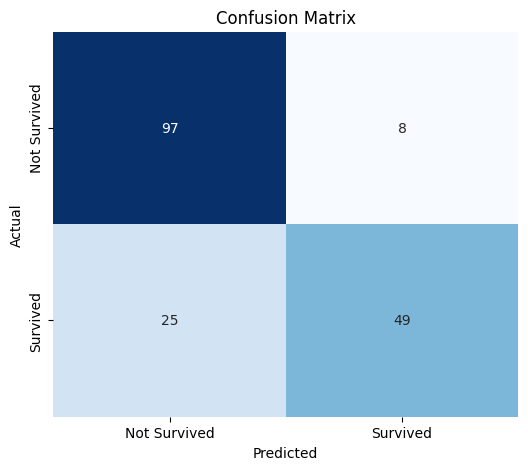

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Reasoning**:
To complete the evaluation, I will calculate the ROC curve and the Area Under the Curve (AUC) using the predicted probabilities and then plot the ROC curve, including the AUC score in the plot as per the subtask instructions.



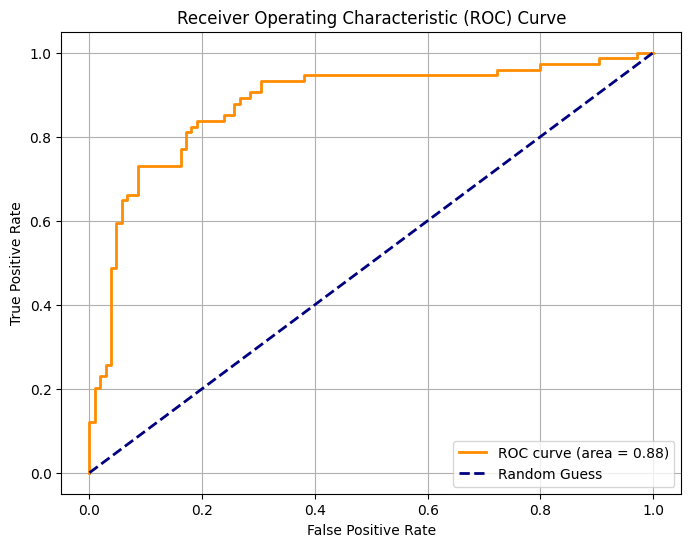

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Final Task





### Data Analysis Key Findings
*   The initial dataset containing 891 entries and 12 columns was successfully loaded.
*   **Data Preprocessing**:
    *   Irrelevant columns such as 'PassengerId', 'Name', 'Ticket', and 'Cabin' were removed.
    *   Missing 'Age' values (177 instances) were imputed with the median (28.0).
    *   Missing 'Embarked' values (2 instances) were imputed with the mode ('S').
    *   Categorical features 'Sex' was numerically encoded (female: 0, male: 1), and 'Embarked' and 'Pclass' were one-hot encoded, expanding the feature set.
    *   Numerical features ('Age', 'Fare', 'SibSp', 'Parch') were scaled using `StandardScaler`.
*   **Data Splitting**: The preprocessed dataset was split into training and testing sets with an 80/20 ratio. The training set comprised 712 samples, and the testing set comprised 179 samples, each with 9 features.
*   **Neural Network Architecture**: A sequential neural network was defined with an explicit input layer (9 features), two hidden layers (64 and 32 neurons, both with ReLU activation), and an output layer (1 neuron with sigmoid activation) for binary classification. The model was compiled using the 'Adam' optimizer, 'binary\_crossentropy' loss, and 'accuracy' metric.
*   **Model Training**: The model was trained for 50 epochs with a batch size of 32.
*   **Model Performance Evaluation**:
    *   The model achieved an accuracy of 0.8156 on the test set.
    *   Precision was 0.8596, indicating a high proportion of correctly identified survivors among all predicted survivors.
    *   Recall was 0.6622, suggesting the model missed a notable portion of actual survivors.
    *   The F1-Score was 0.7481, providing a balanced measure of the model's accuracy.
    *   The Receiver Operating Characteristic (ROC) curve analysis yielded an Area Under the Curve (AUC) of 0.86, indicating good discriminatory power between the survival classes.

